# Ocean Carbon Data & Machine Learning Workshop
### From Observations to ML-based fCO₂ Mapping

**Instructor:** Dr. Laique Djeutchouang  
**Goal:** A very light demo of an end‑to‑end workflow used in modern ocean carbon mapping:

1. Retrieve global Earth system datasets
2. Load and explore NetCDF data
3. Preprocess predictor variables
4. Visualize geospatial fields
5. Train a Machine Learning model to predict surface ocean fCO₂

This notebook is designed for **early‑career researchers and students with limited Python experience**.

## Scientific Context

Surface ocean CO₂ observations are sparse. To estimate the **global ocean carbon sink**, we combine:

- SOCAT ship observations (target variable)
- Satellite and reanalysis predictors

Common predictors include:

| Variable | Dataset |
|---|---|
| Sea Surface Temperature | NOAA OISST |
| Wind Speed | ERA5 |
| Chlorophyll | GlobColour |
| Sea Surface Salinity | Met Office products |

Machine learning models can learn relationships between these predictors and **fCO₂**.

## 1. Install Required Python Libraries

In [6]:
import sys
!{sys.executable} -m pip install xarray netCDF4 pandas numpy matplotlib scikit-learn cartopy requests --quiet


## 2. Import Libraries

In [7]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import requests


## 3. Download Example Datasets

In real research workflows datasets are large. For teaching purposes we download **small demonstration files**.

In [8]:
def download_file(url, filename):
    r = requests.get(url)
    open(filename, 'wb').write(r.content)
    print(f"Downloaded {filename}")

# Example datasets (small samples for teaching)
sst_url = "https://downloads.psl.noaa.gov/Datasets/noaa.oisst.v2.highres/sst.day.mean.2026.nc"

download_file(sst_url, "sst.nc")


Downloaded sst.nc


## 4. Load NetCDF Dataset

In [9]:
sst = xr.open_dataset("sst.nc")
sst


<xarray.Dataset> Size: 315MB
Dimensions:  (time: 76, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 608B 2026-01-01 2026-01-02 ... 2026-03-17
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 315MB ...
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...

In [10]:
print(sst)


<xarray.Dataset> Size: 315MB
Dimensions:  (time: 76, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 608B 2026-01-01 2026-01-02 ... 2026-03-17
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 315MB ...
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...


## 5. Basic Geospatial Visualization

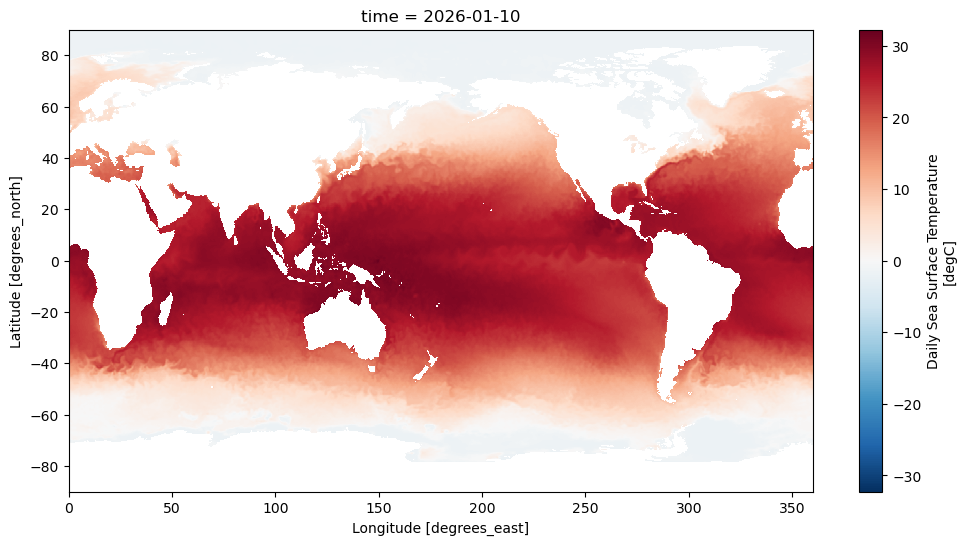

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
sst['sst'].isel(time=9).plot(ax=ax)
# ax.set_title("Global Sea Surface Temperature")
plt.show()


## 6. Create Synthetic SOCAT Training Data

To demonstrate ML without downloading the full SOCAT database, we simulate training samples.

In [12]:
np.random.seed(42)

n = 5000

sst_sample = np.random.normal(20,5,n)
wind_sample = np.random.normal(6,2,n) 
chl_sample = np.random.lognormal(0,1,n)

# synthetic fCO2 relationship
fco2 = 350 + 2*sst_sample + 3*wind_sample - 10*np.log(chl_sample+1) + np.random.normal(0,10,n)

df = pd.DataFrame({
    'sst':sst_sample,
    'wind':wind_sample,
    'chl':chl_sample,
    'fco2':fco2
})

df.head()


,sst,wind,chl,fco2
0,22.483571,5.152481,0.507380,404.886620
1,19.308678,5.093172,0.736755,398.050127
2,23.238443,2.408714,0.550251,399.961808
3,27.615149,5.339820,1.116745,423.219578
4,18.829233,7.465658,3.310763,387.972120


## 7. Train Machine Learning Model

In [13]:
X = df[['sst','wind','chl']]
y = df['fco2']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor(n_estimators=200)
model.fit(X_train,y_train)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,pred))

print("RMSE:",rmse)


RMSE: 10.679754485178105


## 8. Predicted vs Observed

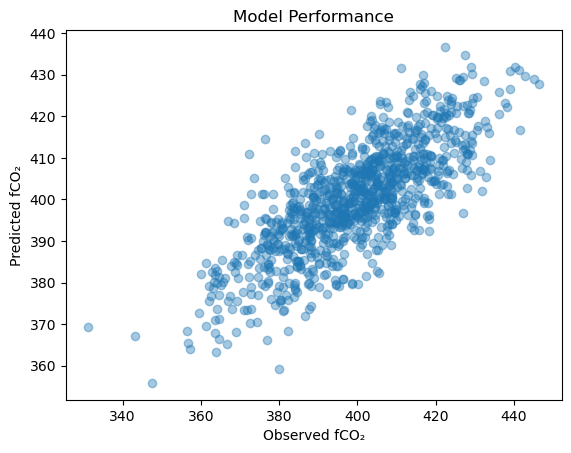

In [14]:
plt.scatter(y_test, pred, alpha=0.4)
plt.xlabel("Observed fCO₂")
plt.ylabel("Predicted fCO₂")
plt.title("Model Performance")
plt.show()


## 9. Applying Model to Gridded Data

In real ocean carbon mapping studies we apply trained models to **global predictor fields** to reconstruct full fCO₂ maps.

## Key Takeaways

This notebook demonstrated the workflow used in modern carbon mapping:

1. Observational data (SOCAT)
2. Environmental predictors
3. Machine learning regression
4. Spatial prediction

These approaches underpin many global ocean carbon products used to estimate the **ocean carbon sink**.